# P7demo

## Importation des librairies

Le module `openpyxl` (dépendance optionnelle de `pandas`) est requis pour lire les fichiers Excel.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Chargement des onglets du fichier Excel

In [2]:
excel_filename = "data/sanitoral.xlsx"

Plusieurs points de vigilance

- Le nombre de lignes avant les entêtes (headers) varie d'un onglet à l'autre.
- Les colonnes avec les identfiants des projets portent des noms différents (toutes renommées `Project ID`).

In [3]:
df_country_profile = pd.read_excel(excel_filename, sheet_name="Country_Profiles", header=1)
df_country_profile.head()

,Country,Region,Type
0,France,Western Europe,Affiliate
1,Belgique,Western Europe,Affiliate
2,Hollande,Western Europe,Affiliate
3,Luxembourg,Western Europe,Affiliate
4,Italie,Western Europe,Affiliate


In [4]:
df_project_location = pd.read_excel(excel_filename, sheet_name="Projects_Locations", header=1)
df_project_location.head()

,Project ID,Country
0,1,Equateur
1,2,France
2,3,Liban
3,4,Egypte
4,5,Afrique du Sud


In [5]:
df_project_type = pd.read_excel(excel_filename, sheet_name="Project type", header=3)
df_project_type.head()

,Project ID,Project Type
0,1,Marketing - Launch of new product
1,2,Marketing - Launch of new product
2,3,Marketing - Launch of new product
3,4,Marketing - Launch of new product
4,5,Marketing - Launch of new product


In [6]:
df_planned = pd.read_excel(excel_filename, sheet_name="Projects_plans", header=2)
df_planned.head()

,Project ID,Phase,Start Date,Planned_Duration,Planned_Cost,Planned_Delivrable
0,1,Phase 1 - Planning,2018-01-16,196,50000,10
1,1,Phase 2 - Initiation,2018-01-31,15,100000,17
2,1,Phase 3 - Implementation,2018-04-17,197,150000,26
3,1,Phase 4 - Manufacturing,2018-10-10,61,450000,23
4,2,Phase 1 - Planning,2018-01-30,16,100000,6


In [7]:
df_actual_cost = pd.read_excel(excel_filename, sheet_name="Actual_Costs", header=3)
df_actual_cost.rename(columns={"Proj_ID":"Project ID"}, inplace=True)
df_actual_cost.head()

,Project ID,Phase,Actual_Cost
0,1,Phase 1 - Planning,59600
1,2,Phase 1 - Planning,86700
2,3,Phase 1 - Planning,65800
3,4,Phase 1 - Planning,65100
4,5,Phase 1 - Planning,52600


In [8]:
df_actual_duration = pd.read_excel(excel_filename, sheet_name="Actual_Duration", header=5)
df_actual_duration.rename(columns={"Project":"Project ID"}, inplace=True)
df_actual_duration.head()

,Project ID,Phase,Actual_Duration
0,1,Phase 1 - Planning,196
1,1,Phase 2 - Initiation,7
2,1,Phase 3 - Implementation,176
3,1,Phase 4 - Manufacturing,64
4,2,Phase 1 - Planning,16


In [9]:
df_actual_deliverable = pd.read_excel(excel_filename, sheet_name="Actual_Delivrable", header=3)
df_actual_deliverable.rename(columns={"ID":"Project ID"}, inplace=True)
df_actual_deliverable.head()

,Project ID,Phase,Actual_Deliverables
0,1,Phase 1 - Planning,10
1,1,Phase 2 - Initiation,16
2,1,Phase 3 - Implementation,25
3,1,Phase 4 - Manufacturing,23
4,2,Phase 1 - Planning,6


## Analyse exploratoire

In [10]:
df_country_profile.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Country  52 non-null     str  
 1   Region   52 non-null     str  
 2   Type     52 non-null     str  
dtypes: str(3)
memory usage: 1.3 KB


In [11]:
df_project_location.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Project ID  104 non-null    int64
 1   Country     104 non-null    str  
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [12]:
df_project_type.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Project ID    104 non-null    int64
 1   Project Type  104 non-null    str  
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [13]:
df_planned.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Project ID          520 non-null    int64         
 1   Phase               520 non-null    str           
 2   Start Date          520 non-null    datetime64[us]
 3   Planned_Duration    520 non-null    int64         
 4   Planned_Cost        520 non-null    int64         
 5   Planned_Delivrable  520 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 24.5 KB


In [14]:
df_actual_duration.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Project ID       520 non-null    int64
 1   Phase            520 non-null    str  
 2   Actual_Duration  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


In [15]:
df_actual_cost.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Project ID   520 non-null    int64
 1   Phase        520 non-null    str  
 2   Actual_Cost  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


In [16]:
df_actual_deliverable.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Project ID           520 non-null    int64
 1   Phase                520 non-null    str  
 2   Actual_Deliverables  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


## Jointure

In [17]:
df_merge = pd.merge(df_country_profile, df_project_location)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Country     104 non-null    str  
 1   Region      104 non-null    str  
 2   Type        104 non-null    str  
 3   Project ID  104 non-null    int64
dtypes: int64(1), str(3)
memory usage: 3.4 KB


In [18]:
df_merge = pd.merge(df_merge, df_project_type)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Country       104 non-null    str  
 1   Region        104 non-null    str  
 2   Type          104 non-null    str  
 3   Project ID    104 non-null    int64
 4   Project Type  104 non-null    str  
dtypes: int64(1), str(4)
memory usage: 4.2 KB


In [19]:
df_merge = pd.merge(df_merge, df_planned)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Country             520 non-null    str           
 1   Region              520 non-null    str           
 2   Type                520 non-null    str           
 3   Project ID          520 non-null    int64         
 4   Project Type        520 non-null    str           
 5   Phase               520 non-null    str           
 6   Start Date          520 non-null    datetime64[us]
 7   Planned_Duration    520 non-null    int64         
 8   Planned_Cost        520 non-null    int64         
 9   Planned_Delivrable  520 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(5)
memory usage: 40.8 KB


In [20]:
df_merge = pd.merge(df_merge, df_actual_duration)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Country             520 non-null    str           
 1   Region              520 non-null    str           
 2   Type                520 non-null    str           
 3   Project ID          520 non-null    int64         
 4   Project Type        520 non-null    str           
 5   Phase               520 non-null    str           
 6   Start Date          520 non-null    datetime64[us]
 7   Planned_Duration    520 non-null    int64         
 8   Planned_Cost        520 non-null    int64         
 9   Planned_Delivrable  520 non-null    int64         
 10  Actual_Duration     520 non-null    int64         
dtypes: datetime64[us](1), int64(5), str(5)
memory usage: 44.8 KB


In [21]:
df_merge = pd.merge(df_merge, df_actual_cost)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Country             520 non-null    str           
 1   Region              520 non-null    str           
 2   Type                520 non-null    str           
 3   Project ID          520 non-null    int64         
 4   Project Type        520 non-null    str           
 5   Phase               520 non-null    str           
 6   Start Date          520 non-null    datetime64[us]
 7   Planned_Duration    520 non-null    int64         
 8   Planned_Cost        520 non-null    int64         
 9   Planned_Delivrable  520 non-null    int64         
 10  Actual_Duration     520 non-null    int64         
 11  Actual_Cost         520 non-null    int64         
dtypes: datetime64[us](1), int64(6), str(5)
memory usage: 48.9 KB


In [22]:
df_merge = pd.merge(df_merge, df_actual_deliverable)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Country              520 non-null    str           
 1   Region               520 non-null    str           
 2   Type                 520 non-null    str           
 3   Project ID           520 non-null    int64         
 4   Project Type         520 non-null    str           
 5   Phase                520 non-null    str           
 6   Start Date           520 non-null    datetime64[us]
 7   Planned_Duration     520 non-null    int64         
 8   Planned_Cost         520 non-null    int64         
 9   Planned_Delivrable   520 non-null    int64         
 10  Actual_Duration      520 non-null    int64         
 11  Actual_Cost          520 non-null    int64         
 12  Actual_Deliverables  520 non-null    int64         
dtypes: datetime64[us](1), int64(7), str(5)
memory 

In [23]:
for project_type in sorted(pd.unique(df_merge["Project Type"])):
    df_tmp = df_merge[ (df_merge["Project Type"] == project_type) ]
    n = df_tmp.shape[0]
    print(*sorted(pd.unique(df_tmp["Phase"])), sep="\n")
    df_tmp = df_tmp[["Project ID","Phase"]].groupby("Project ID").agg({ "Phase": [ "count", "nunique" ] })
    # reshape() : 1 seul argument pour passer d'une matrice (2D) à un vecteur (1D)
    # -1 signifie "calcul automatique de la taille du vecteur" (nb lignes × nb colonnes)
    a = pd.unique(df_tmp.to_numpy().reshape(-1))
    assert len(a) == 1
    m = a[0]
    print(f"Les {n // m} projets de type ({project_type}) ont tous {m} phases.")

Phase A - Initiation
Phase B - Preparation
Phase C - Development
Phase D - Testing
Phase E - Deployment
Phase F - Post-deployment
Les 52 projets de type (IT -  CRM Implementation) ont tous 6 phases.
Phase 1 - Planning
Phase 2 - Initiation
Phase 3 - Implementation
Phase 4 - Manufacturing
Les 52 projets de type (Marketing - Launch of new product) ont tous 4 phases.


## Calculs

In [24]:
df_merge["Delay"]         = (df_merge["Actual_Duration"] - df_merge["Planned_Duration"]).clip(lower=0) # max(0, actual - planned)
df_merge["Is_Late"]       = (df_merge["Delay"] > 0)
df_merge["Start_Month"]   = df_merge["Start Date"].dt.month
df_merge["Start_Quarter"] = df_merge["Start Date"].dt.quarter
df_merge["Start_Year"]    = df_merge["Start Date"].dt.year
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Country              520 non-null    str           
 1   Region               520 non-null    str           
 2   Type                 520 non-null    str           
 3   Project ID           520 non-null    int64         
 4   Project Type         520 non-null    str           
 5   Phase                520 non-null    str           
 6   Start Date           520 non-null    datetime64[us]
 7   Planned_Duration     520 non-null    int64         
 8   Planned_Cost         520 non-null    int64         
 9   Planned_Delivrable   520 non-null    int64         
 10  Actual_Duration      520 non-null    int64         
 11  Actual_Cost          520 non-null    int64         
 12  Actual_Deliverables  520 non-null    int64         
 13  Delay                520 non-null    int64    

## Agrégation

In [25]:
df_project = df_merge.groupby("Project ID").agg({
    "Planned_Duration": "sum",
    "Planned_Cost": "sum",
    "Planned_Delivrable": "sum",
    "Phase": "count",
    "Delay": "sum",
    "Is_Late": "any",
    "Start Date": "min",
}).reset_index()
df_project.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Project ID          104 non-null    int64         
 1   Planned_Duration    104 non-null    int64         
 2   Planned_Cost        104 non-null    int64         
 3   Planned_Delivrable  104 non-null    int64         
 4   Phase               104 non-null    int64         
 5   Delay               104 non-null    int64         
 6   Is_Late             104 non-null    bool          
 7   Start Date          104 non-null    datetime64[us]
dtypes: bool(1), datetime64[us](1), int64(6)
memory usage: 5.9 KB


## Visualisation

In [26]:
df_tmp = df_project[["Project ID","Delay"]].groupby("Delay").count().reset_index()
df_tmp.rename(columns={"Project ID":"Project Count"}, inplace=True)
delay_min = df_tmp["Delay"].min()
delay_max = df_tmp["Delay"].max()
count_max = df_tmp["Project Count"].max()
print(f"Le retard cumulé par projet varie entre {delay_min} et {delay_max}.")
print(f"Il y a au plus {count_max} projet(s) par valeur de retard cumulé.")

Le retard cumulé par projet varie entre 0 et 163.
Il y a au plus 9 projet(s) par valeur de retard cumulé.


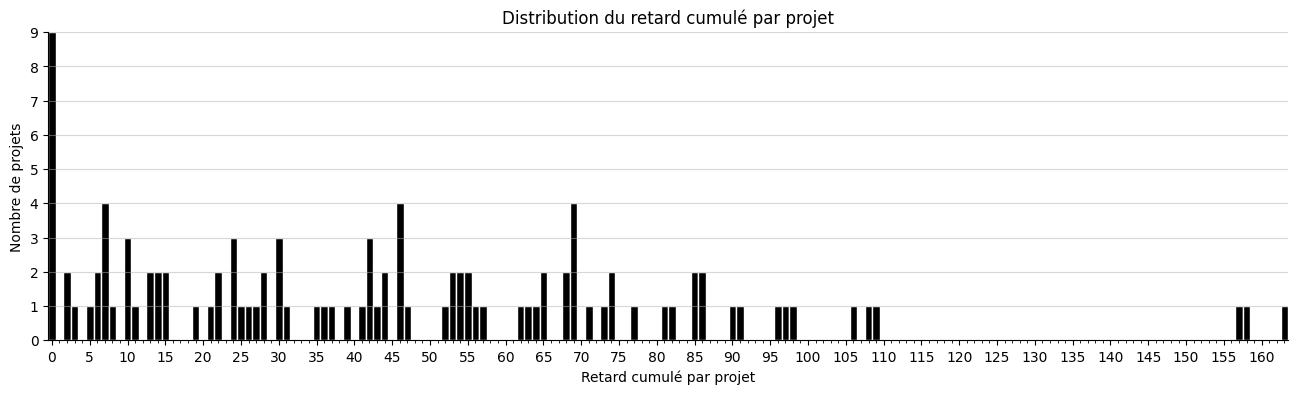

In [27]:
bins = np.arange(delay_min, delay_max + 2) - 0.5 # no bins
ax = df_project["Delay"].plot.hist(bins=bins, color="black", edgecolor="white", figsize=(16,4))
plt.title("Distribution du retard cumulé par projet")
plt.ylabel("Nombre de projets")
plt.xlabel("Retard cumulé par projet")
plt.xlim(delay_min - 0.5, delay_max + 0.5)
plt.xticks(range(0,delay_max+1,5))
plt.xticks(range(0,delay_max+1), minor=True)
plt.ylim(0, 9)
plt.yticks(range(0,count_max+1))
plt.grid(axis="y", alpha=.5)
ax.spines["top"   ].set_visible(False)
ax.spines["right" ].set_visible(False)
plt.show()